# Brain Tumor Classification & Segmentation — Comparative Study

A systematic comparison of multiple CNN architectures for **brain tumor classification** (4-class: glioma, meningioma, pituitary, no tumor) and **brain tumor segmentation** (binary tumor masks) on the **BRISC2025** MRI dataset.

**Goal:** train every model under identical conditions (same data split, preprocessing, augmentation, optimizer, and evaluation protocol), then select the best classification model and best segmentation model based on experimental results — not by assumption.

**Dataset:** [BRISC2025](https://www.kaggle.com/datasets/briscdataset/brisc2025) — 6000+ T1-weighted MRI slices with expert-annotated tumor masks.

**Pipeline overview:**
1. Setup & environment
2. Download and verify BRISC2025
3. Shared utilities (seeding, early stopping)
4. Fixed train/val/test splits (generated once, reused by every model)
5. Shared augmentation + dataset pipeline (identical for every model)
6. Classification model factory (8 CNN architectures)
7. Segmentation model factory (8 architectures)
8. Training loops
9. Evaluation & comparison tables

---

## Phase 1 — Environment Setup

Mounts Google Drive (used as persistent storage across Colab sessions, since Colab's local disk is wiped on every disconnect), installs required packages, and creates the project folder structure.

**Run this first in every session** — `PROJECT_ROOT` is required by every subsequent cell, and Colab wipes all variables when the runtime disconnects or restarts.

In [20]:
# Mount Google Drive and set the project path used throughout the notebook.

from google.colab import drive
import os
import sys

drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/brain-tumor-study'

SRC_PATH = os.path.join(PROJECT_ROOT, 'src')

if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

print("Project root:", PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/brain-tumor-study


In [21]:
# Install the libraries used for image augmentation, model training,
# and model analysis, then make sure the main project folders exist.

!pip install -q albumentations timm thop

import os

REQUIRED_FOLDERS = [
    'data/raw',
    'data/splits',
    'data/external',
    'src',
    'results/classification',
]

for folder in REQUIRED_FOLDERS:
    os.makedirs(
        os.path.join(PROJECT_ROOT, folder),
        exist_ok=True
    )

print("Project setup completed.")

Project setup completed.


In [22]:
# Check that the source modules and saved data splits are available
# before moving on to the dataset preparation steps.

src_files = os.listdir(os.path.join(PROJECT_ROOT, 'src'))
split_files = os.listdir(os.path.join(PROJECT_ROOT, 'data', 'splits'))

print("src/ contains:", src_files)
print("data/splits/ contains:", split_files)

src/ contains: ['__pycache__', 'models_segmentation.py', 'train_segmentation.py', 'utils.py', 'make_splits.py', 'augmentations.py', 'brisc_datasets.py', 'models_classification.py', 'train_classification.py']
data/splits/ contains: ['segmentation_split.json', 'classification_split.json']


## Phase 2 — Download & Extract BRISC2025

This phase downloads the BRISC2025 dataset to Colab's local storage, verifies the classification files, extracts the dataset locally, and then stores the verified copy in Google Drive.

The dataset is extracted locally first because working with thousands of small files directly on mounted Drive can be slow.

**Requires:** a Kaggle API token (`kaggle.json`) from Kaggle → Settings → API → Create Legacy API Key.

In [23]:
# Download the BRISC2025 dataset from Kaggle to Colab's local storage.
# The downloaded archive is kept locally until its classification files
# are checked and extracted successfully.

from google.colab import files
import os
import shutil

# Upload Kaggle API credentials.
print("Upload your kaggle.json:")
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)

shutil.move(
    'kaggle.json',
    '/root/.kaggle/kaggle.json'
)

os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Store the downloaded archive on Colab's local disk.
local_download_dir = '/content/brisc_download'
os.makedirs(local_download_dir, exist_ok=True)

!pip install -q kaggle

!kaggle datasets download \
    -d briscdataset/brisc2025 \
    -p {local_download_dir}

zip_path = f'{local_download_dir}/brisc2025.zip'

print("\nDownloaded archive:")
!ls -lh {zip_path}

# Check that the expected classification files are present.
print("\nClassification training images:")
!unzip -l {zip_path} | grep -E "classification_task/train/.+\.jpg$" | wc -l

print("Classification test images:")
!unzip -l {zip_path} | grep -E "classification_task/test/.+\.jpg$" | wc -l

Upload your kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/briscdataset/brisc2025
License(s): Attribution 4.0 International (CC BY 4.0)
brisc2025.zip: Skipping, found more recently modified local copy (use --force to force download)

Downloaded archive:
-rw-r--r-- 1 root root 251M Nov  4  2025 /content/brisc_download/brisc2025.zip

Classification training images:
5000
Classification test images:
1000


In [24]:
# Extract the verified archive locally, check the classification data,
# and then copy the dataset to the existing project directory on Drive.

import os
import shutil

local_download_dir = '/content/brisc_download'
zip_path = f'{local_download_dir}/brisc2025.zip'
local_extract_dir = '/content/brisc_extracted'

# Start with a clean local extraction directory.
if os.path.exists(local_extract_dir):
    shutil.rmtree(local_extract_dir)

print("Extracting dataset locally...")
!unzip -q {zip_path} -d {local_extract_dir}
print("Extraction complete.")

# The archive contains a top-level 'brisc2025' directory.
extracted_root = f'{local_extract_dir}/brisc2025'

cls_train_root = f'{extracted_root}/classification_task/train'
cls_test_root = f'{extracted_root}/classification_task/test'

# Check the extracted classification dataset.
print("\nClassification training images by class:")

for class_name in sorted(os.listdir(cls_train_root)):
    class_dir = os.path.join(cls_train_root, class_name)

    if os.path.isdir(class_dir):
        image_count = len([
            f for f in os.listdir(class_dir)
            if f.lower().endswith('.jpg')
        ])
        print(f"  {class_name}: {image_count}")

print(
    "\nClassification test images:",
    sum(
        len([
            f for f in os.listdir(
                os.path.join(cls_test_root, class_name)
            )
            if f.lower().endswith('.jpg')
        ])
        for class_name in os.listdir(cls_test_root)
        if os.path.isdir(os.path.join(cls_test_root, class_name))
    )
)

# Copy the verified dataset to the project directory on Drive.
dest = f'{PROJECT_ROOT}/data/raw/brisc2025'

if os.path.exists(dest):
    print("\nDataset already exists on Drive.")
    print("Existing Drive copy has been kept unchanged.")
else:
    print("\nCopying dataset to Drive...")
    shutil.copytree(extracted_root, dest)
    print("Dataset copied successfully.")

print("\nDrive dataset:", dest)
print("Contents:", os.listdir(dest))

Extracting dataset locally...
Extraction complete.

Classification training images by class:
  glioma: 1147
  meningioma: 1329
  no_tumor: 1067
  pituitary: 1457

Classification test images: 1000

Dataset already exists on Drive.
Existing Drive copy has been kept unchanged.

Drive dataset: /content/drive/MyDrive/brain-tumor-study/data/raw/brisc2025
Contents: ['README.md', 'classification_task', 'manifest.csv', 'manifest.csv.sha256', 'manifest.json', 'manifest.json.sha256', 'segmentation_task']


In [25]:
# Verify that the classification dataset is available on Drive
# and that all four classes contain the expected training images.

dest = f'{PROJECT_ROOT}/data/raw/brisc2025'
drive_cls_train = f'{dest}/classification_task/train'

print("Classification training images on Drive:")

total_images = 0

for class_name in sorted(os.listdir(drive_cls_train)):
    class_dir = os.path.join(drive_cls_train, class_name)

    if os.path.isdir(class_dir):
        image_count = len([
            f for f in os.listdir(class_dir)
            if f.lower().endswith('.jpg')
        ])

        total_images += image_count
        print(f"  {class_name}: {image_count}")

print(f"\nTotal training images: {total_images}")
print("Drive dataset verification completed.")

Classification training images on Drive:
  glioma: 1147
  meningioma: 1329
  no_tumor: 1067
  pituitary: 1457

Total training images: 5000
Drive dataset verification completed.


## Phase 3 — Shared Utilities

This phase creates `src/utils.py` with the common utilities used throughout the classification experiments: reproducible seeding, JSON helpers, and early stopping.

In [26]:
# Create the shared utilities used across all classification experiments.
# Keeping these functions in one module ensures the training runs follow
# the same reproducibility and early-stopping settings.

utils_code = '''
"""Utilities shared across the classification training pipeline."""

import json
import os
import random

import numpy as np
import torch


def set_seed(seed: int):
    """Set random seeds for reproducible experiments."""

    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def save_json(obj, path):
    """Save a Python object as a formatted JSON file."""

    with open(path, "w") as f:
        json.dump(obj, f, indent=2)


def load_json(path):
    """Load and return a JSON file."""

    with open(path) as f:
        return json.load(f)


class EarlyStopping:
    """Stop training when a monitored metric stops improving."""

    def __init__(self, patience=10, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best = None
        self.counter = 0
        self.should_stop = False

    def step(self, value):
        """Update the stopping state using the current metric value."""

        if self.best is None:
            self.best = value
            return False

        improved = (
            value > self.best
            if self.mode == "max"
            else value < self.best
        )

        if improved:
            self.best = value
            self.counter = 0
        else:
            self.counter += 1

            if self.counter >= self.patience:
                self.should_stop = True

        return self.should_stop
'''

with open(f'{PROJECT_ROOT}/src/utils.py', 'w') as f:
    f.write(utils_code)

print("utils.py written successfully.")

utils.py written successfully.


## Phase 4 — Fixed Train/Validation Split

A fixed split ensures that all six classification models are trained and validated on the same images, making the comparison consistent across architectures.

BRISC2025 already provides separate `train/` and `test/` sets. Here, the provided training set is split 80/20 into training and validation sets, while the original `test/` set remains untouched for later evaluation.

In [27]:
# Create the utility used to generate the fixed classification
# train/validation split. The same seed keeps the split identical
# across all model experiments.

make_splits_code = '''
"""Utilities for creating reproducible classification data splits."""

import glob
import json
import os
import random


def make_classification_split(
    cls_train_dir,
    out_path,
    val_fraction=0.2,
    seed=42
):
    """Create and save a reproducible train/validation split.

    The BRISC2025 classification training set is split within each
    class so that the class distribution is preserved.

    Args:
        cls_train_dir: Directory containing one folder per class.
        out_path: Path where the split JSON file will be saved.
        val_fraction: Fraction of each class used for validation.
        seed: Random seed for reproducibility.

    Returns:
        A dictionary containing the class names and split samples.
    """

    random.seed(seed)

    classes = sorted(os.listdir(cls_train_dir))

    train_files = []
    val_files = []

    for class_name in classes:
        class_dir = os.path.join(cls_train_dir, class_name)

        files = sorted(
            glob.glob(os.path.join(class_dir, "*.jpg"))
        )

        random.shuffle(files)

        n_val = int(len(files) * val_fraction)

        val_files.extend(
            [(filepath, class_name) for filepath in files[:n_val]]
        )

        train_files.extend(
            [(filepath, class_name) for filepath in files[n_val:]]
        )

    split = {
        "classes": classes,
        "train": train_files,
        "val": val_files,
    }

    with open(out_path, "w") as f:
        json.dump(split, f, indent=2)

    print(
        f"Classification split saved: "
        f"{len(train_files)} train, {len(val_files)} val"
    )

    return split
'''

with open(f'{PROJECT_ROOT}/src/make_splits.py', 'w') as f:
    f.write(make_splits_code)

print("make_splits.py written successfully.")

make_splits.py written successfully.


In [28]:
# Create the fixed 80/20 classification train/validation split.
# This file is reused for every model so that all six models
# train and validate on the same images.

from make_splits import make_classification_split

PATH_CLS = (
    f'{PROJECT_ROOT}/data/raw/brisc2025/classification_task'
)

cls_split = make_classification_split(
    cls_train_dir=f'{PATH_CLS}/train',
    out_path=f'{PROJECT_ROOT}/data/splits/classification_split.json'
)

Classification split saved: 4002 train, 998 val


In [29]:
# Check the generated split and confirm that the expected classes
# and train/validation sample counts are present.

print("Classes found:", cls_split["classes"])

print(
    "Classification — train/val counts:",
    len(cls_split["train"]),
    len(cls_split["val"])
)

print("Sample train entry:", cls_split["train"][0])

Classes found: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Classification — train/val counts: 4002 998
Sample train entry: ('/content/drive/MyDrive/brain-tumor-study/data/raw/brisc2025/classification_task/train/glioma/brisc2025_train_00058_gl_ax_t1.jpg', 'glioma')


## Phase 5 — Shared Augmentation & Dataset Pipeline

These modules provide the common image preprocessing and data-loading pipeline used by all six classification models. Using the same pipeline keeps the architecture comparison consistent.

- `augmentations.py` — defines the shared training and evaluation transforms using Albumentations and ImageNet normalization.
- `brisc_datasets.py` — provides the PyTorch dataset and DataLoader utilities for the classification split.

**Naming note:** The dataset module is named `brisc_datasets.py` instead of `datasets.py` to avoid conflicts with the Hugging Face `datasets` package.

In [30]:
# Define the common image transforms used by all classification models.
# Training uses light augmentation, while validation and test images
# are only resized and normalized.

augmentations_code = '''
"""Image preprocessing and augmentation for classification."""

import albumentations as A
from albumentations.pytorch import ToTensorV2


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def get_classification_train_transforms(img_size=224):
    """Return the training augmentation pipeline."""

    return A.Compose([
        A.Resize(img_size, img_size),

        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),

        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=0.3
        ),

        A.Affine(
            translate_percent=0.05,
            scale=(0.9, 1.1),
            rotate=(-15, 15),
            p=0.3
        ),

        A.GaussNoise(
            std_range=(0.04, 0.2),
            p=0.2
        ),

        A.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD
        ),

        ToTensorV2(),
    ])


def get_classification_eval_transforms(img_size=224):
    """Return the evaluation pipeline without augmentation."""

    return A.Compose([
        A.Resize(img_size, img_size),

        A.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD
        ),

        ToTensorV2(),
    ])
'''

with open(f'{PROJECT_ROOT}/src/augmentations.py', 'w') as f:
    f.write(augmentations_code)

print("augmentations.py written successfully.")

augmentations.py written successfully.


In [31]:
# Create the PyTorch dataset and DataLoader utilities used by the
# classification experiments. All six models use these same loaders.

datasets_code = '''
"""PyTorch dataset and DataLoader utilities for BRISC2025 classification."""

import numpy as np
import torch

from PIL import Image
from torch.utils.data import Dataset, DataLoader


class BRISCClassificationDataset(Dataset):
    """Load image and class-label pairs from the saved split."""

    def __init__(self, samples, class_to_idx, transform=None):
        self.samples = samples
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filepath, classname = self.samples[idx]

        image = Image.open(filepath).convert("RGB")
        image = np.array(image)

        label = self.class_to_idx[classname]

        if self.transform:
            image = self.transform(image=image)["image"]

        return image, label


def get_classification_loaders(
    split_json,
    images_root_unused,
    batch_size,
    train_transform,
    eval_transform,
    num_workers=2
):
    """Create train and validation DataLoaders from the saved split."""

    classes = split_json["classes"]
    class_to_idx = {
        class_name: idx
        for idx, class_name in enumerate(classes)
    }

    train_dataset = BRISCClassificationDataset(
        split_json["train"],
        class_to_idx,
        train_transform
    )

    val_dataset = BRISCClassificationDataset(
        split_json["val"],
        class_to_idx,
        eval_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,# Convert the saved experiment summaries into a DataFrame so the
# results can be easily inspected, plotted, and compared.

import pandas as pd

results_df = pd.DataFrame(all_results)

if not results_df.empty:
    results_df["params_m"] = (
        results_df["total_params"] / 1e6
…    display(results_df)

else:
    print("No classification results available.")
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    return train_loader, val_loader, class_to_idx
'''

with open(f'{PROJECT_ROOT}/src/brisc_datasets.py', 'w') as f:
    f.write(datasets_code)

print("brisc_datasets.py written successfully.")

brisc_datasets.py written successfully.


In [32]:
# Load one batch through the classification pipeline to make sure
# the split, transforms, dataset, and DataLoader are working together.
#
# If augmentations.py or brisc_datasets.py was edited earlier in this
# session, restart the runtime before running this cell so the updated
# modules are loaded.

from brisc_datasets import get_classification_loaders
from augmentations import (
    get_classification_train_transforms,
    get_classification_eval_transforms,
)
from utils import load_json

# Load the fixed classification split.
cls_split = load_json(
    f'{PROJECT_ROOT}/data/splits/classification_split.json'
)

# Build the training and validation DataLoaders.
train_loader, val_loader, class_to_idx = get_classification_loaders(
    cls_split,
    None,
    batch_size=8,
    train_transform=get_classification_train_transforms(224),
    eval_transform=get_classification_eval_transforms(224)
)

print("Class-to-index mapping:", class_to_idx)

# Load one training batch as a final pipeline check.
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Pipeline check passed.")

Class-to-index mapping: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
Images: torch.Size([8, 3, 224, 224])
Labels: torch.Size([8])
Pipeline check passed.


## Phase 6 — Classification Model Factory

This phase defines a common model factory for the six classification architectures evaluated in this study: **VGG19, ResNet50, DenseNet121, EfficientNet-B0, EfficientNet-B1, and EfficientNet-B4**.

All models are created through the same interface using `timm`, with ImageNet-pretrained weights and a four-class output layer.

In [33]:
# Create the model factory used to build all six classification models.
# Keeping model creation in one place makes it easier to train and
# compare the architectures using the same setup.

models_classification_code = '''
"""Model factory for the classification architectures used in this study.

Supported models:
    VGG19
    ResNet50
    DenseNet121
    EfficientNet-B0
    EfficientNet-B1
    EfficientNet-B4
"""

import timm


MODEL_REGISTRY = {
    "vgg19": "vgg19",
    "resnet50": "resnet50",
    "densenet121": "densenet121",
    "efficientnet_b0": "efficientnet_b0",
    "efficientnet_b1": "efficientnet_b1",
    "efficientnet_b4": "efficientnet_b4",
}

CLASSIFICATION_MODEL_NAMES = list(MODEL_REGISTRY.keys())


def get_classification_model(
    name: str,
    num_classes: int = 4,
    pretrained: bool = True,
    freeze_strategy: str = "none"
):
    """Build a classification model from the supported architectures.

    Args:
        name: Model name from CLASSIFICATION_MODEL_NAMES.
        num_classes: Number of output classes.
        pretrained: Whether to use ImageNet-pretrained weights.
        freeze_strategy:
            "none"    - Keep all parameters trainable.
            "partial" - Freeze approximately the first 75% of parameters.
            "full"    - Freeze all parameters except the classifier head.

    Returns:
        A configured timm classification model.
    """

    if name not in MODEL_REGISTRY:
        raise ValueError(
            f"Unknown model '{name}'. "
            f"Choose from: {CLASSIFICATION_MODEL_NAMES}"
        )

    model = timm.create_model(
        MODEL_REGISTRY[name],
        pretrained=pretrained,
        num_classes=num_classes
    )

    if freeze_strategy == "full":
        _freeze_all_but_head(model)

    elif freeze_strategy == "partial":
        _freeze_partial(model)

    elif freeze_strategy != "none":
        raise ValueError(
            f"Unknown freeze strategy '{freeze_strategy}'. "
            "Choose from: none, partial, full."
        )

    return model


def _freeze_all_but_head(model):
    """Freeze all parameters except the final classifier head."""

    for param in model.parameters():
        param.requires_grad = False

    classifier = model.get_classifier()

    for param in classifier.parameters():
        param.requires_grad = True


def _freeze_partial(model):
    """Freeze approximately 75% of parameters.

    The remaining parameters, including the later layers and
    classifier head, remain trainable.
    """

    all_params = list(model.named_parameters())
    cutoff = int(len(all_params) * 0.75)

    for i, (_, param) in enumerate(all_params):
        param.requires_grad = i >= cutoff


def count_parameters(model):
    """Return total and trainable parameter counts."""

    total_params = sum(
        param.numel()
        for param in model.parameters()
    )

    trainable_params = sum(
        param.numel()
        for param in model.parameters()
        if param.requires_grad
    )

    return total_params, trainable_params
'''

with open(f'{PROJECT_ROOT}/src/models_classification.py', 'w') as f:
    f.write(models_classification_code)

print("models_classification.py written successfully.")

models_classification.py written successfully.


In [34]:
# Check that all six classification models can be created and produce
# the expected four-class output for a standard 224x224 RGB input.

import torch

from models_classification import (
    get_classification_model,
    CLASSIFICATION_MODEL_NAMES,
    count_parameters,
)


dummy_input = torch.randn(2, 3, 224, 224)

print(
    f"{'Model':<20} "
    f"{'Output shape':<20} "
    f"{'Total params (M)':<20} "
    f"{'Trainable (M)'}"
)
print("-" * 75)

for name in CLASSIFICATION_MODEL_NAMES:
    model = get_classification_model(
        name,
        num_classes=4
    )

    model.eval()

    with torch.no_grad():
        output = model(dummy_input)

    total, trainable = count_parameters(model)

    print(
        f"{name:<20} "
        f"{str(tuple(output.shape)):<20} "
        f"{total / 1e6:<20.2f} "
        f"{trainable / 1e6:.2f}"
    )

    # Release the current model before building the next one.
    del model

Model                Output shape         Total params (M)     Trainable (M)
---------------------------------------------------------------------------


model.safetensors: reconstructing file:   0%|          |  0.00B /  575MB            

model.safetensors: downloading bytes:           |  0.00B            

vgg19                (2, 4)               139.59               139.59


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

...

model.safetensors: downloading bytes:           |  0.00B            

efficientnet_b1      (2, 4)               6.52                 6.52


model.safetensors: reconstructing file:   0%|          |  0.00B / 77.9MB            

model.safetensors: downloading bytes:           |  0.00B            

efficientnet_b4      (2, 4)               17.56                17.56


## Phase 8 — Classification Training Loop

`train_classification.py` contains the shared training loop used for all six classification models. The same data split, augmentation pipeline, optimizer, learning-rate scheduler, and early-stopping settings are used for each architecture so that their results can be compared consistently.

In [36]:
# Create the shared training loop used by all six classification models.
# Each model follows the same training and validation procedure so the
# results can be compared under the same experimental setup.

code = '''
"""Training utilities for the BRISC2025 classification experiments."""

import os
import time

import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
from torch.optim.lr_scheduler import ReduceLROnPlateau

from augmentations import (
    get_classification_train_transforms,
    get_classification_eval_transforms,
)
from brisc_datasets import get_classification_loaders
from models_classification import (
    get_classification_model,
    count_parameters,
)
from utils import set_seed, save_json, EarlyStopping


def train_classification_model(
    model_name,
    project_root,
    cls_split,
    seed=42,
    batch_size=32,
    lr=1e-4,
    max_epochs=50,
    patience=10,
    img_size=224,
    device=None,
):
    """Train and evaluate one classification model."""

    set_seed(seed)

    device = device or (
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    run_dir = os.path.join(
        project_root,
        "results",# Convert the saved experiment summaries into a DataFrame so the
# results can be easily inspected, plotted, and compared.

import pandas as pd

results_df = pd.DataFrame(all_results)

if not results_df.empty:
    results_df["params_m"] = (
        results_df["total_params"] / 1e6
…    display(results_df)

else:
    print("No classification results available.")
        "classification",
        model_name,
        f"seed_{seed}",
    )

    os.makedirs(run_dir, exist_ok=True)

    # Build the train and validation loaders using the shared pipeline.
    train_loader, val_loader, class_to_idx = get_classification_loaders(
        cls_split,
        None,
        batch_size=batch_size,
        train_transform=get_classification_train_transforms(img_size),
        eval_transform=get_classification_eval_transforms(img_size),
        num_workers=2,
    )

    num_classes = len(class_to_idx)

    # Build the selected model with ImageNet-pretrained weights.
    model = get_classification_model(
        model_name,
        num_classes=num_classes,
    ).to(device)

    total_params, trainable_params = count_parameters(model)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
    )

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=4,
    )

    criterion = nn.CrossEntropyLoss()

    early_stopper = EarlyStopping(
        patience=patience,
        mode="max",
    )

    history = []
    best_val_acc = -1.0
    best_epoch = -1

    best_ckpt_path = os.path.join(
        run_dir,
        "best_model.pt",
    )

    separator = "=" * 60

    print(f"\\n{separator}")
    print(f"Training {model_name} (seed={seed}) on {device}")
    print(separator)

    print(
        f"Total params: {total_params / 1e6:.2f}M | "
        f"Trainable: {trainable_params / 1e6:.2f}M"
    )

    for epoch in range(max_epochs):
        epoch_start = time.time()

        # Training
        model.train()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            train_correct += (
                predictions == labels
            ).sum().item()

            train_total += labels.size(0)

        train_loss /= train_total
        train_acc = train_correct / train_total

        # Validation
        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                predictions = outputs.argmax(dim=1)

                val_correct += (
                    predictions == labels
                ).sum().item()

                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        scheduler.step(val_acc)

        epoch_time = time.time() - epoch_start

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "epoch_time_sec": epoch_time,
        })

        print(
            f"Epoch {epoch + 1}/{max_epochs} | "
            f"train_loss={train_loss:.4f} "
            f"train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} "
            f"val_acc={val_acc:.4f} | "
            f"time={epoch_time:.1f}s"
        )

        # Save the checkpoint with the best validation accuracy.
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch

            torch.save(
                model.state_dict(),
                best_ckpt_path,
            )

        if early_stopper.step(val_acc):
            print(
                f"Early stopping at epoch {epoch + 1} "
                f"(best val_acc={best_val_acc:.4f} "
                f"at epoch {best_epoch + 1})"
            )
            break

    # Evaluate the best checkpoint on the validation set.
    model.load_state_dict(
        torch.load(
            best_ckpt_path,
            map_location=device,
        )
    )

    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)

            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            predictions = outputs.argmax(dim=1)

            all_preds.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

            all_probs.extend(
                probabilities.cpu().numpy()
            )

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            all_labels,
            all_preds,
            average="macro",
            zero_division=0,
        )
    )

    try:
        macro_auc = roc_auc_score(
            all_labels,
            all_probs,
            multi_class="ovr",
            average="macro",
        )
    except ValueError:
        macro_auc = None

    summary = {
        "model_name": model_name,
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_acc": best_val_acc,
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
        "macro_auc": (
            float(macro_auc)
            if macro_auc is not None
            else None
        ),
        "total_params": total_params,
        "trainable_params": trainable_params,
        "avg_epoch_time_sec": float(
            np.mean(
                [h["epoch_time_sec"] for h in history]
            )
        ),
        "num_epochs_trained": len(history),
    }

    # Save the training history and experiment summary.
    save_json(
        history,
        os.path.join(run_dir, "history.json"),
    )

    save_json(
        summary,
        os.path.join(run_dir, "summary.json"),
    )

    print(f"\\n{separator}")

    print(
        f"Finished {model_name}: "
        f"best_val_acc={best_val_acc:.4f} "
        f"(epoch {best_epoch + 1}), "
        f"macro_f1={f1:.4f}"
    )

    print(separator)

    return summary
'''

with open(
    f'{PROJECT_ROOT}/src/train_classification.py',
    'w'
) as f:
    f.write(code)

# Check the generated Python file before using it for training.
import py_compile

path = f'{PROJECT_ROOT}/src/train_classification.py'

try:
    py_compile.compile(path, doraise=True)
    print("Syntax check passed.")
except py_compile.PyCompileError as e:
    print("Syntax check failed:")
    print(e)

Syntax check passed.


In [37]:
# Copy the classification images to Colab's local storage for training.
# The local copy is created once per session and avoids repeatedly reading
# thousands of image files from the mounted Drive.

import os
import shutil
import time

src = f'{PROJECT_ROOT}/data/raw/brisc2025/classification_task'
dst = '/content/brisc_cls'

if not os.path.exists(dst):
    print("Copying classification dataset to local storage...")

    start = time.time()

    shutil.copytree(src, dst)

    elapsed_minutes = (
        time.time() - start
    ) / 60

    print(
        f"Dataset copied in {elapsed_minutes:.1f} minutes."
    )
else:
    print("Classification dataset is already on local storage.")

print("\nTraining images:")

for class_name in sorted(
    os.listdir(f'{dst}/train')
):
    class_dir = os.path.join(
        dst,
        'train',
        class_name
    )

    image_count = len([
        f for f in os.listdir(class_dir)
        if f.lower().endswith('.jpg')
    ])

    print(
        f"  train/{class_name}: {image_count} images"
    )

Copying classification dataset to local storage...
Dataset copied in 0.3 minutes.

Training images:
  train/glioma: 1147 images
  train/meningioma: 1329 images
  train/no_tumor: 1067 images
  train/pituitary: 1457 images


In [ ]:
# Load the fixed split, switch its image paths to the local dataset copy,
# and start training one of the six classification models.

import os

from train_classification import train_classification_model
from utils import load_json


# Load the same split used by every model.
cls_split = load_json(
    f'{PROJECT_ROOT}/data/splits/classification_split.json'
)


def remap_paths(samples, old_prefix, new_prefix):
    """Replace the Drive dataset path with the local dataset path."""

    return [
        (
            filepath.replace(old_prefix, new_prefix),
            label
        )
        for filepath, label in samples
    ]


old_prefix = (
    f'{PROJECT_ROOT}/data/raw/brisc2025/classification_task'
)

new_prefix = '/content/brisc_cls'


cls_split['train'] = remap_paths(
    cls_split['train'],
    old_prefix,
    new_prefix
)

cls_split['val'] = remap_paths(
    cls_split['val'],
    old_prefix,
    new_prefix
)


# Make sure the local dataset path is valid before training.
print("Sample path:", cls_split['train'][0][0])
print(
    "File exists:",
    os.path.exists(cls_split['train'][0][0])
)


# Change only model_name when training a different architecture.
summary = train_classification_model(
    model_name="vgg19",
    project_root=PROJECT_ROOT,
    cls_split=cls_split,
    seed=42,
    batch_size=16,
    max_epochs=50,
)

print("\nExperiment summary:")
print(summary)

## Phase 9 — Evaluation & Comparison

This phase collects the saved results from all six classification experiments and presents them in a common table. The models are compared using validation accuracy, macro-averaged precision, recall, F1-score, AUC, parameter count, and training epochs.

In [40]:
# Convert the saved experiment summaries into a DataFrame so the
# results can be easily inspected, plotted, and compared.

import pandas as pd

results_df = pd.DataFrame(all_results)

if not results_df.empty:
    results_df["params_m"] = (
        results_df["total_params"] / 1e6
    )

    results_df = results_df[
        [
            "model_name",
            "best_val_acc",
            "macro_precision",
            "macro_recall",
            "macro_f1",
            "macro_auc",
            "params_m",
            "num_epochs_trained",
            "avg_epoch_time_sec",
        ]
    ]

    results_df = results_df.rename(
        columns={
            "model_name": "Model",
            "best_val_acc": "Validation Accuracy",
            "macro_precision": "Macro Precision",
            "macro_recall": "Macro Recall",
            "macro_f1": "Macro F1",
            "macro_auc": "Macro AUC",
            "params_m": "Parameters (M)",
            "num_epochs_trained": "Epochs",
            "avg_epoch_time_sec": "Avg Epoch Time (s)",
        }
    )

    display(results_df)

else:
    print("No classification results available.")

,Model,Validation Accuracy,Macro Precision,Macro Recall,Macro F1,Macro AUC,Parameters (M),Epochs,Avg Epoch Time (s)
0,vgg19,0.993988,0.994071,0.993582,0.993818,0.999787,139.586628,40,111.725466
1,efficientnet_b0,0.993988,0.994360,0.994360,0.994360,0.999821,4.012672,41,25.506340
2,densenet121,0.992986,0.993124,0.993100,0.993100,0.999895,6.957956,23,45.362418
3,efficientnet_b1,0.991984,0.991869,0.992159,0.992005,0.999794,6.518308,26,33.672258
4,resnet50,0.986974,0.986838,0.987692,0.987231,0.999586,23.516228,24,50.380348
5,efficientnet_b4,0.983968,0.984622,0.984100,0.984334,0.999311,17.555788,43,62.350001


In [45]:
# Load the saved training histories so the learning behaviour of
# each classification model can be inspected across epochs.

import json
import os
import matplotlib.pyplot as plt

results_dir = f'{PROJECT_ROOT}/results/classification'

histories = {}

for model_name in model_names:

    history_path = (
        f'{results_dir}/{model_name}/seed_42/history.json'
    )

    if os.path.exists(history_path):

        with open(history_path) as f:
            histories[model_name] = json.load(f)

print(
    f"Loaded histories for {len(histories)} models."
)

Loaded histories for 6 models.


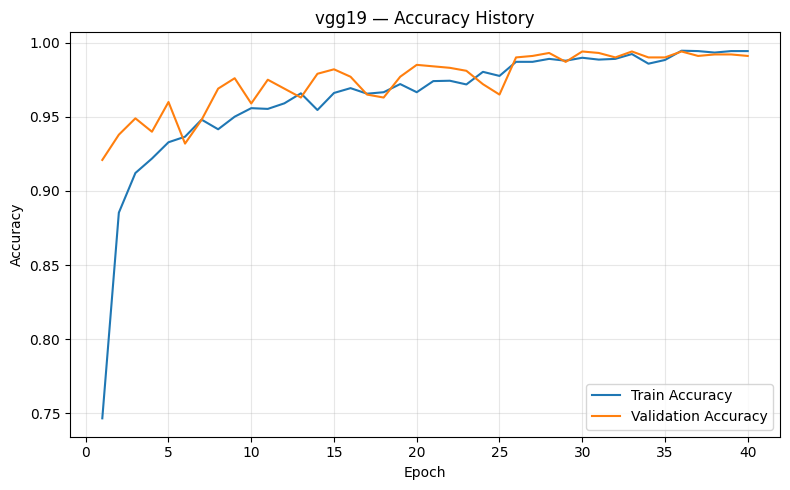

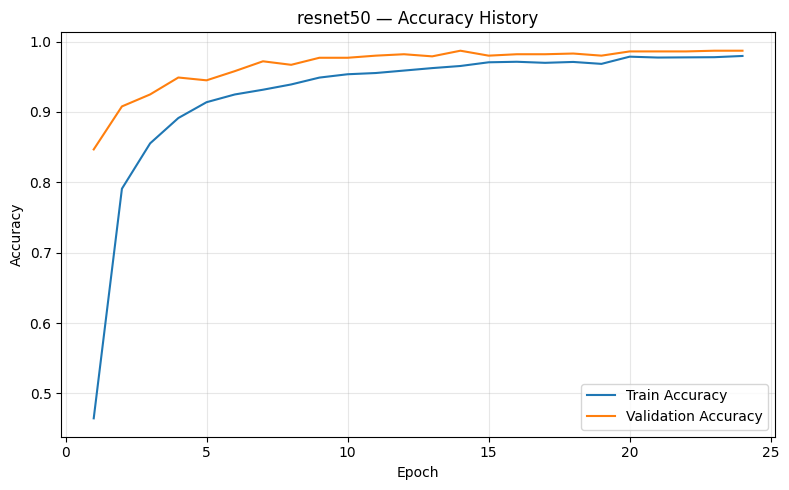

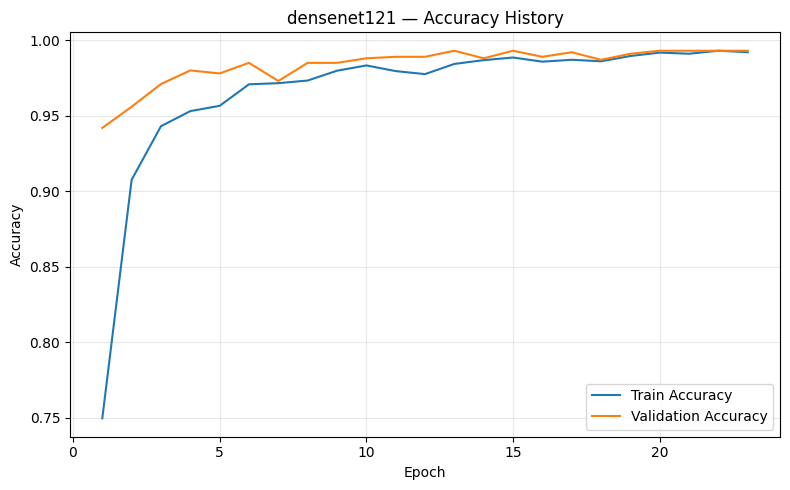

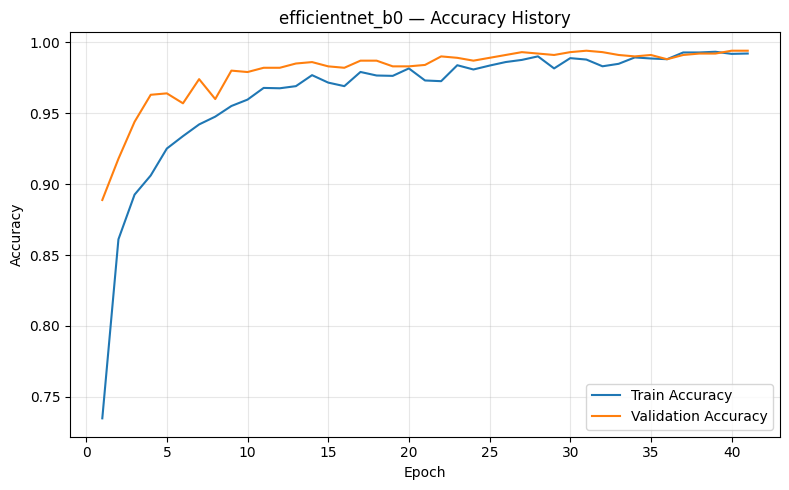

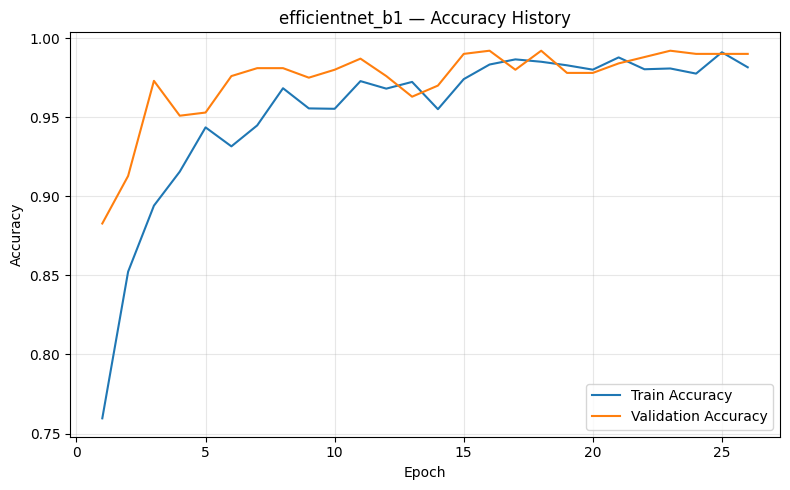

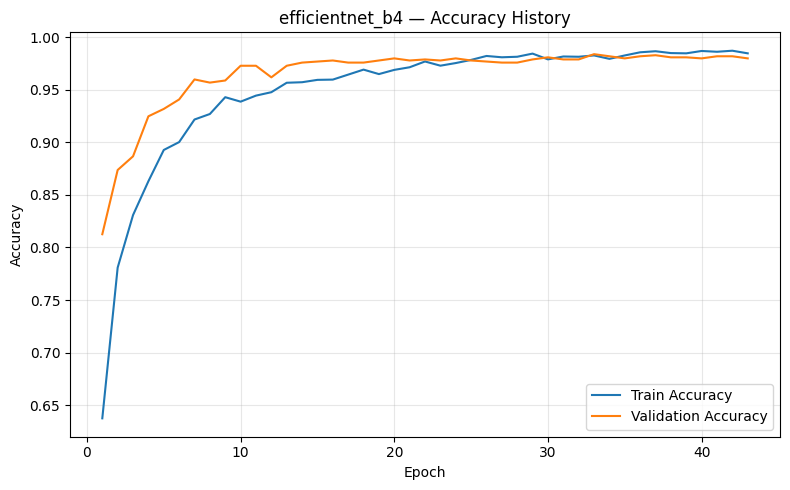

In [46]:
# Plot training and validation accuracy for each model to inspect
# convergence and possible overfitting during training.

import matplotlib.pyplot as plt

for model_name, history in histories.items():

    epochs = [
        item["epoch"] + 1
        for item in history
    ]

    train_acc = [
        item["train_acc"]
        for item in history
    ]

    val_acc = [
        item["val_acc"]
        for item in history
    ]

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        train_acc,
        label="Train Accuracy"
    )

    plt.plot(
        epochs,
        val_acc,
        label="Validation Accuracy"
    )

    plt.title(
        f"{model_name} — Accuracy History"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

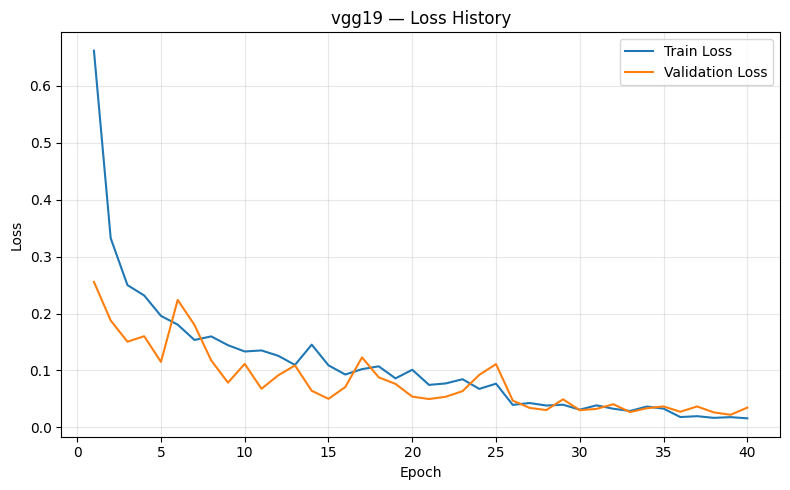

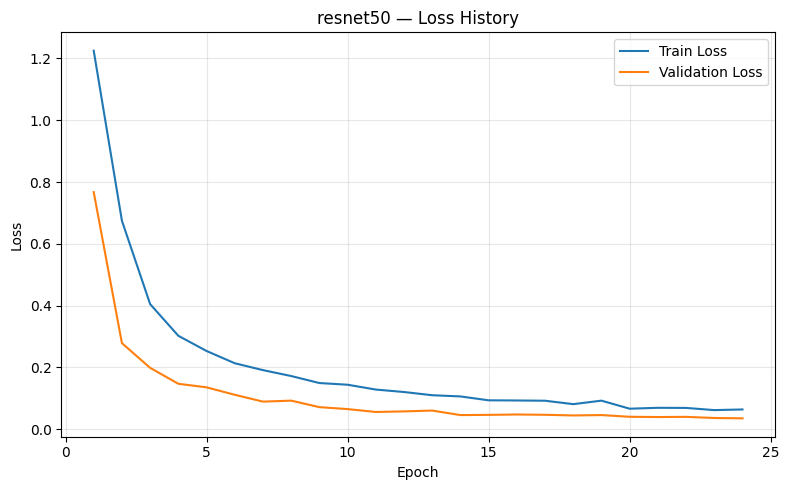

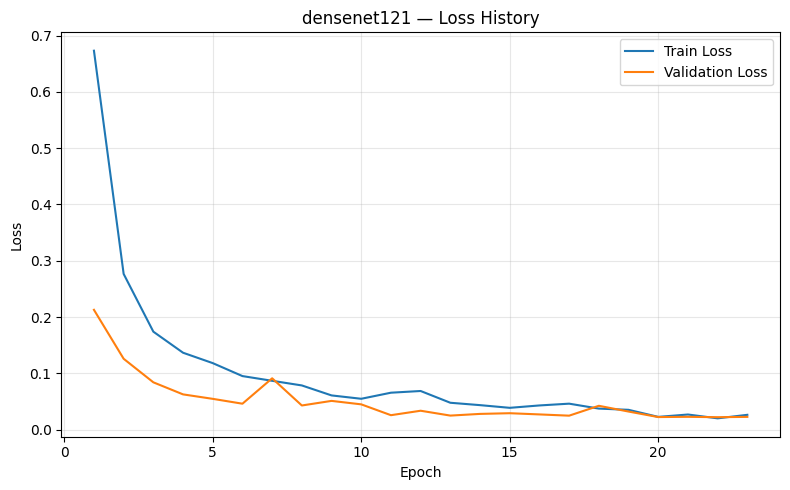

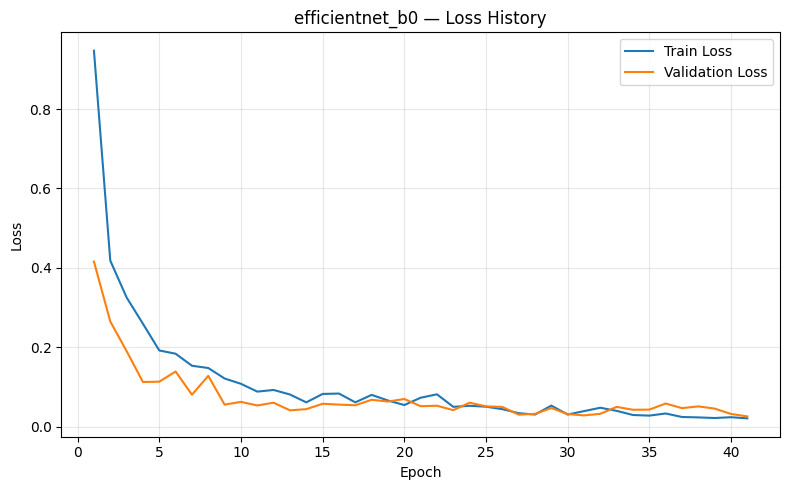

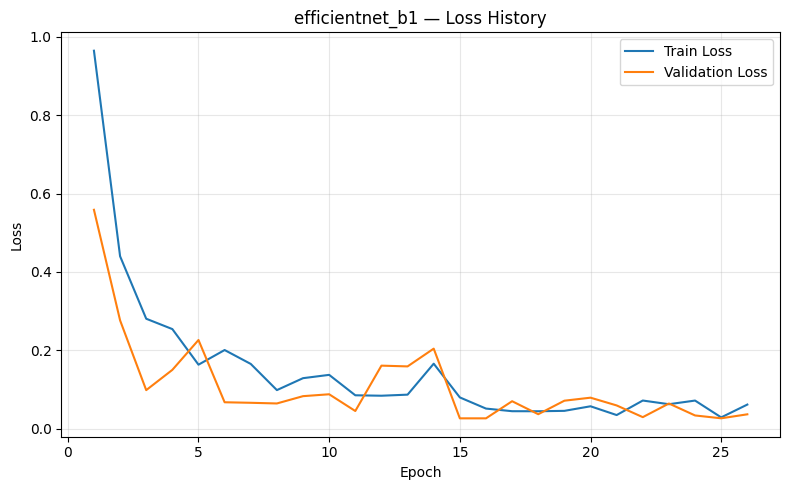

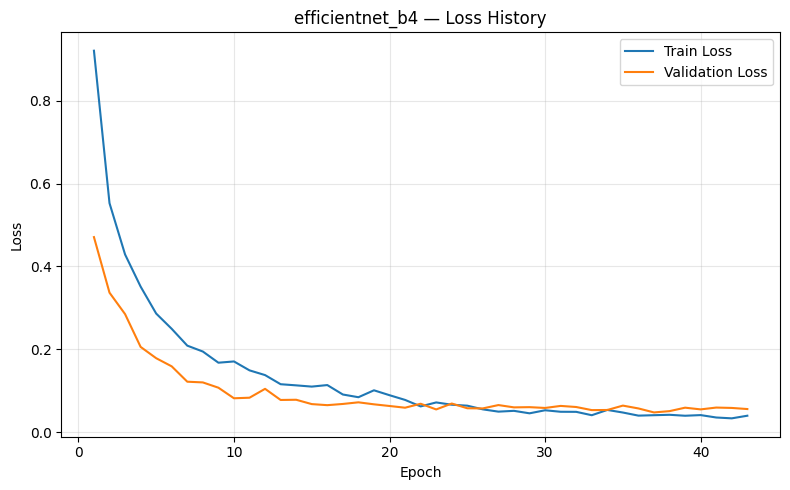

In [47]:
# Plot training and validation loss for each model to examine
# convergence and identify potential overfitting.

import matplotlib.pyplot as plt

for model_name, history in histories.items():

    epochs = [
        item["epoch"] + 1
        for item in history
    ]

    train_loss = [
        item["train_loss"]
        for item in history
    ]

    val_loss = [
        item["val_loss"]
        for item in history
    ]

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        train_loss,
        label="Train Loss"
    )

    plt.plot(
        epochs,
        val_loss,
        label="Validation Loss"
    )

    plt.title(
        f"{model_name} — Loss History"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [49]:
# Save the final comparison table so the experiment results can be
# reused outside the notebook without retraining the models.

comparison_path = (
    f'{PROJECT_ROOT}/results/classification/'
    'classification_comparison.csv'
)

results_df.to_csv(
    comparison_path,
    index=False
)

print(
    "Comparison results saved to:"
)
print(comparison_path)

Comparison results saved to:
/content/drive/MyDrive/brain-tumor-study/results/classification/classification_comparison.csv
